# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business. 

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [1]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [2]:
# read the data
df = pd.read_csv('foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [82]:
# Write your code here
df.shape

(1898, 9)

#### Observations:
The data is a 1898x9 matrix, containing 1898 rows and 9 columns.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [83]:
# Use info() to print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:

- 'order_id' and 'customer_id' are unique ids identifying the order and customer and they are represented as Integer
- 'restaurant_name' and 'cuisine_type' are attributes of the restaurant and they are represented as String (object)
- 'cost_of_the_order' is represented as float because the value also contains decimals
- 'day_of_the_week' is represented as String (object) because it has two categorical values (weekend/weekday)
- 'rating' is represented as String (object) because the representation of a missing rating is "Not given"
- 'food_preparation_time' and 'delivery_time' are represented as Integers because they have fixed minutes values


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [84]:
# Write your code here
df.isna().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

#### Observations:
There are no missing values in any of the variables in the data. 
The column 'rating' has the "valid" missing values already treated as "Not given" value instead of empty.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [85]:
# Write your code here
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


In [86]:
df.describe()['food_preparation_time']

count    1898.000000
mean       27.371970
std         4.632481
min        20.000000
25%        23.000000
50%        27.000000
75%        31.000000
max        35.000000
Name: food_preparation_time, dtype: float64

#### Observations:
- The minimum time it takes for food to be prepared is 20 minutes.
- The maximum time it takes for food to be prepared is 35 minutes.
- The average time it takes for food to be prepared is 27.37 minutes.

### **Question 5:** How many orders are not rated? [1 mark]

In [87]:
# Write the code here
rating_is_not_given = df['rating'] == 'Not given' # predicate to check if the rating is not given       
not_given_count = int(rating_is_not_given.sum()) # count the number of orders that are not rated
print("The number of orders that are not rated is", not_given_count) 

The number of orders that are not rated is 736


In [88]:
df['rating'].value_counts(normalize=True) # visualize the distribution of the ratings

rating
Not given    0.387777
5            0.309800
4            0.203372
3            0.099052
Name: proportion, dtype: float64

#### Observations:
There are 736 orders that are not rated, out of a total of 1898, meaning 38.7%.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

#### Order ID variable analysis


Unique order IDs: 1898


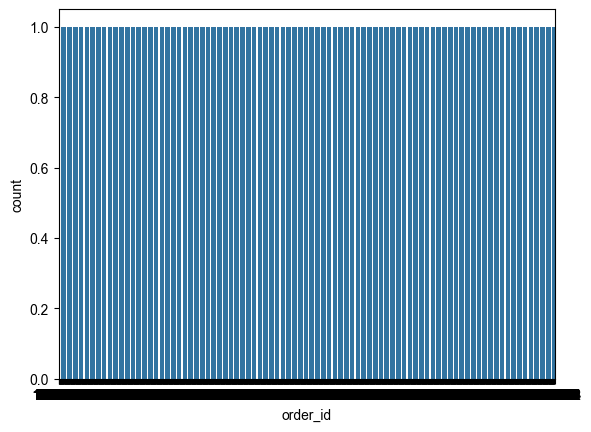

In [89]:
print("Unique order IDs:", df['order_id'].nunique())
sns.countplot(data=df, x='order_id')
plt.show()


#### Observations:
For "order_id" variable there is no univariate analysis to be performed since each value is unique in the dataframe, confirmed both by counting the unique values and also by the plot above.


#### Customer ID variable analysis


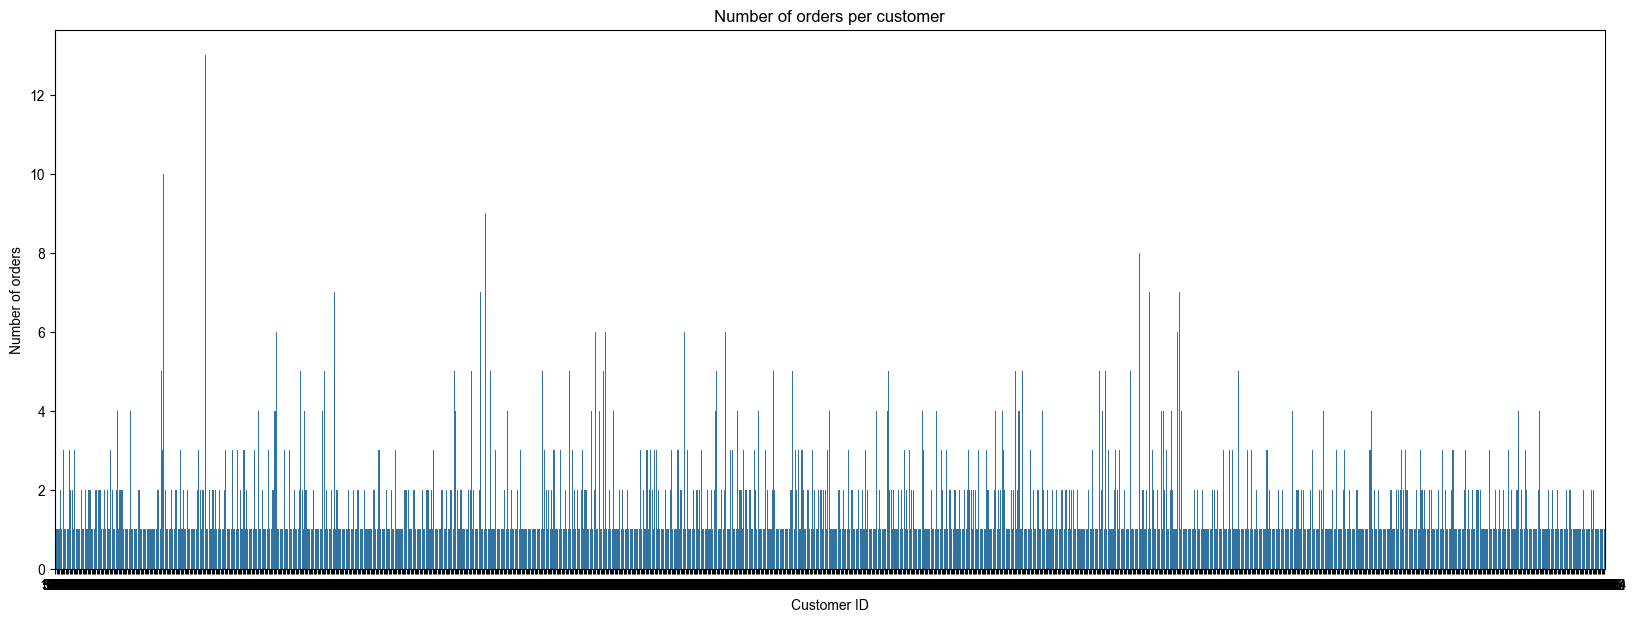

In [90]:
plt.figure(figsize=(20,7)) # set the figure size
sns.countplot(data=df, x='customer_id') # plot the count of orders per customer
plt.ylabel("Number of orders") # set the y-axis label
plt.xlabel("Customer ID") # set the x-axis label
plt.title("Number of orders per customer") # set the title
plt.show() 

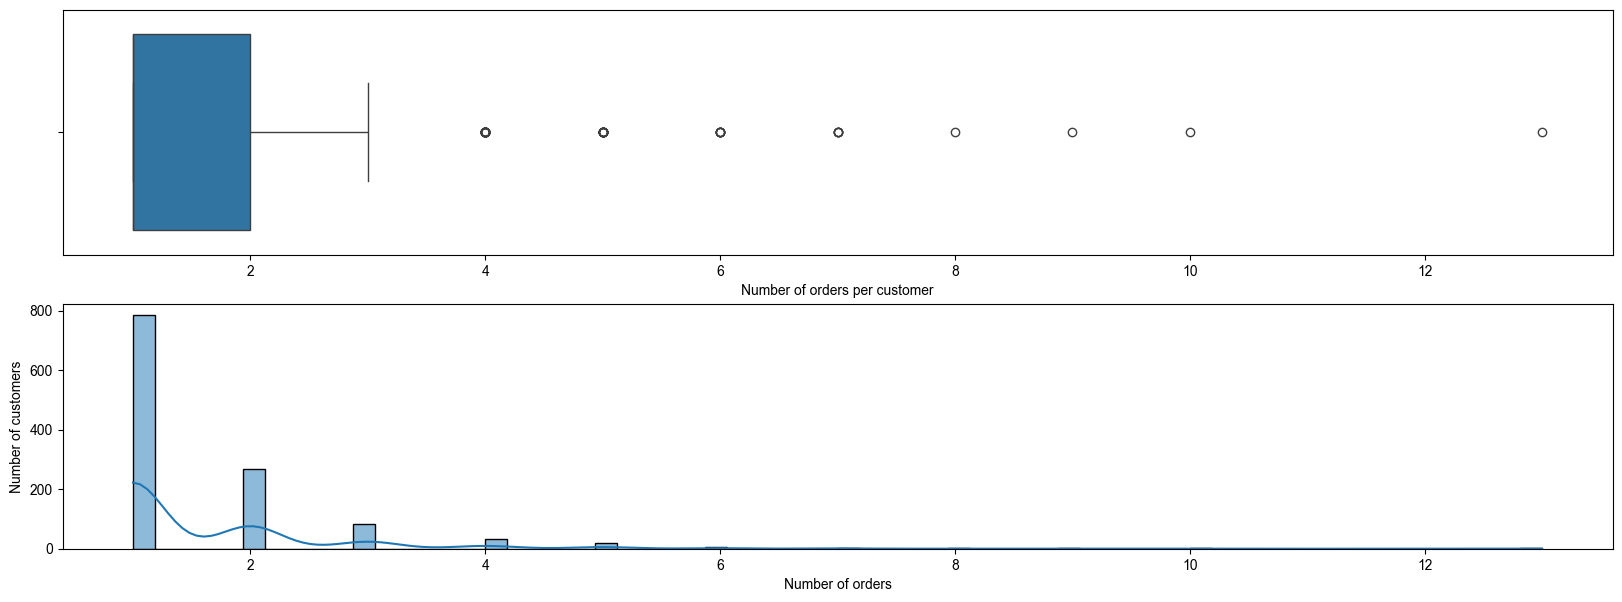

In [91]:
orders_by_customer = df['customer_id'].value_counts() # count the number of orders per customer

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 7)) # create a figure with two subplots
ax1.set_xlabel("Number of orders per customer") # set the x-axis label   
sns.boxplot(data=orders_by_customer, ax=ax1, orient='h') # plot the boxplot

sns.histplot(data=orders_by_customer, kde=True, ax=ax2) # plot the histogram
ax2.set_ylabel("Number of customers") # set the y-axis label
ax2.set_xlabel("Number of orders") # set the x-axis label
plt.show() 


#### Observations:
By looking only at the histogram for 'customer id' variable, it can be seen that the the majority of customers placed 1 order (sometimes 2), but there are also few ones that placed more than 2.
To better asses this, I plotted the same information (the number of customers and the orders) but from a different perspective, with the number of orders on X-axis and on Y-axis the number of customers placing that number of orders.
This better shows us that:
- the distribution of number of orders by 'customer_id' is right-skewed
- both the mean and median are low, indicating in general a low number of orders per customer
- there are outliers in the data, towards the right, where customers had more than 4 orders

#### Restaurant name variable analysis


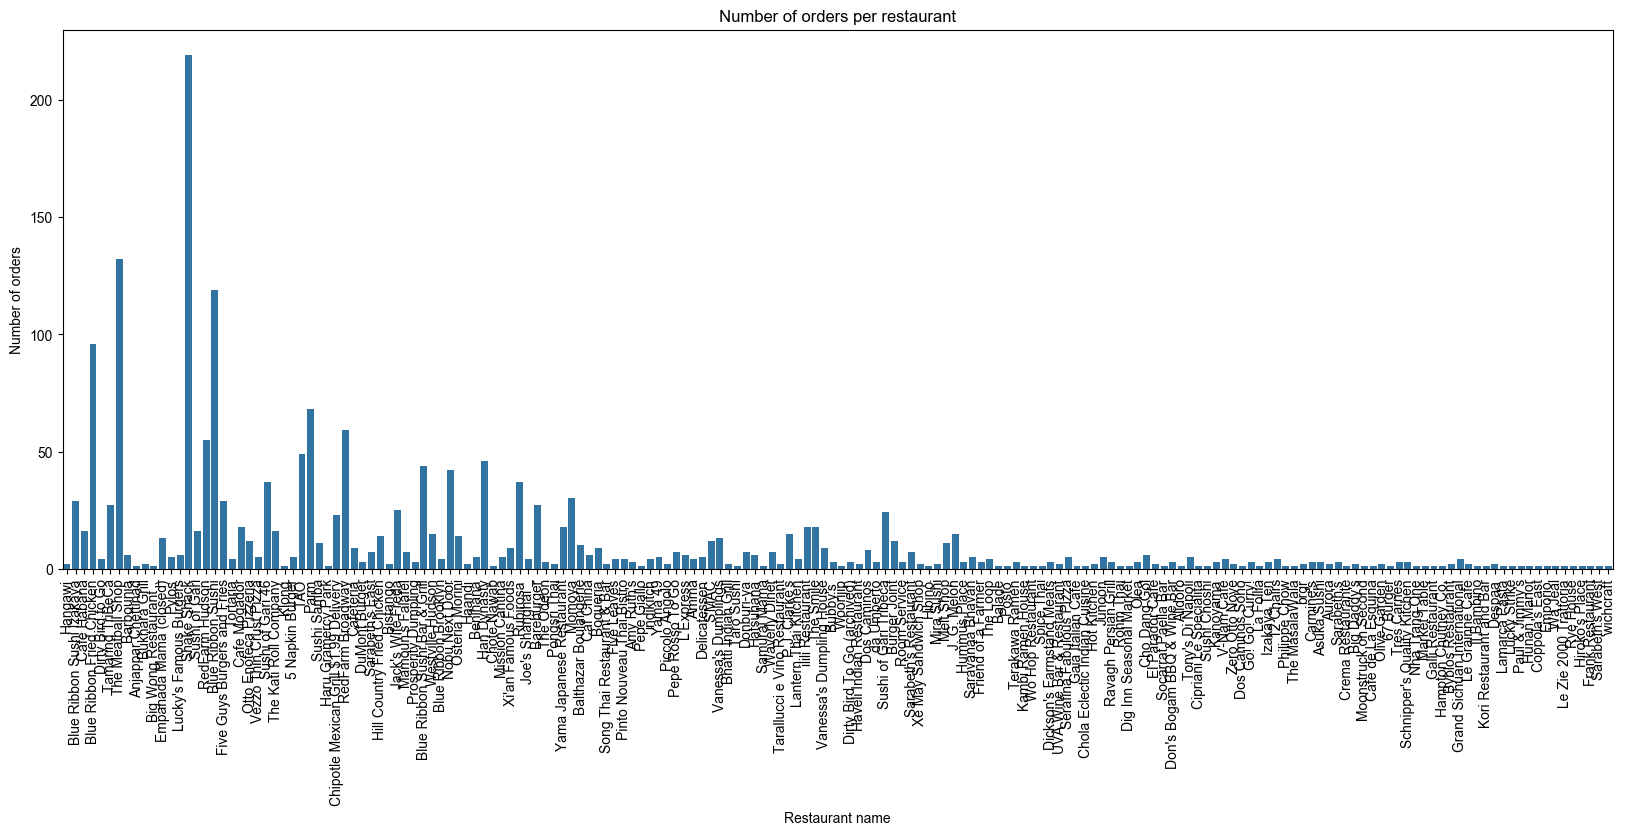

In [92]:
plt.figure(figsize=(20,7)) # set the figure size
standardised_names_characters = df.copy() # copy the dataframe to avoid modifying the original one
standardised_names_characters['restaurant_name'] = standardised_names_characters['restaurant_name'].map(lambda x: x.encode('ascii', 'ignore').decode()) # to avoid warnings of non standard characters being used in the plot

sns.countplot(data=standardised_names_characters, x='restaurant_name') # plot the count of orders per restaurant
plt.ylabel("Number of orders") # set the y-axis label
plt.xlabel("Restaurant name") # set the x-axis label
plt.xticks(rotation=90) # rotate the x-axis labels
plt.title("Number of orders per restaurant") # set the title
plt.show() 

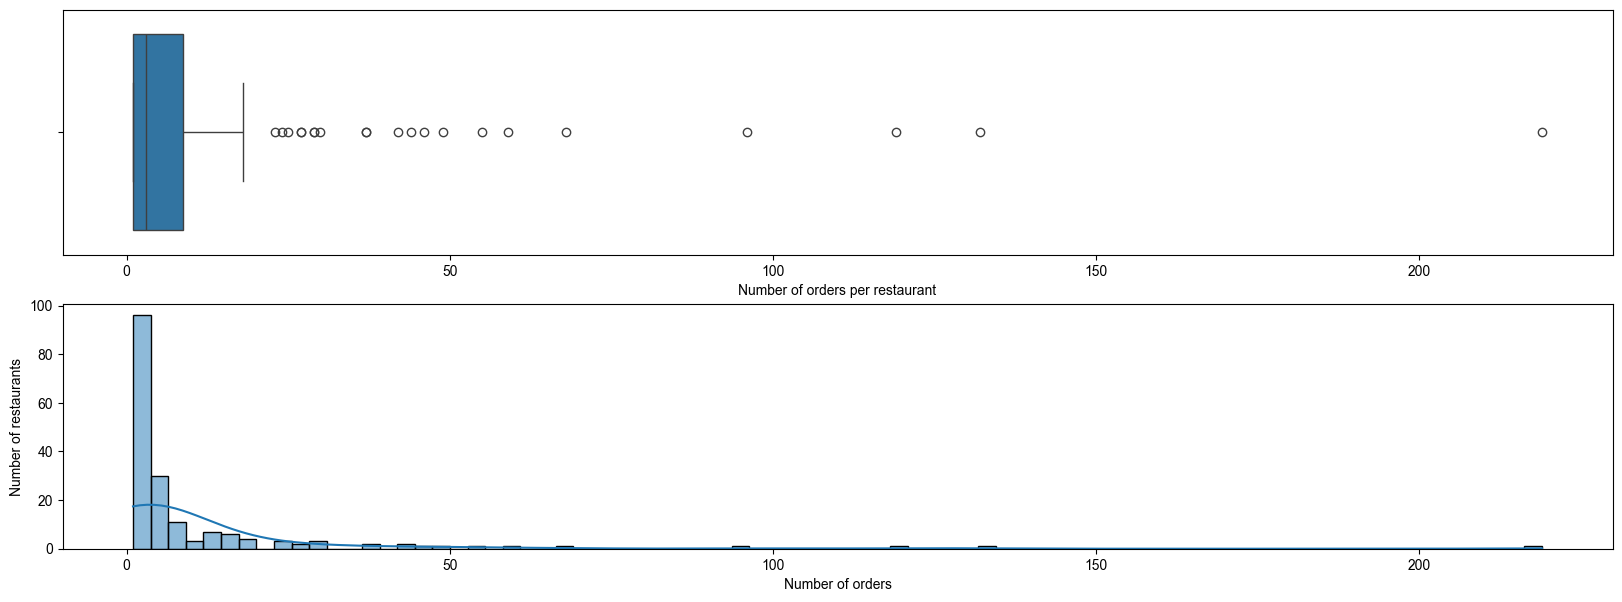

In [93]:
orders_by_restaurant = df['restaurant_name'].value_counts() # count the number of orders per restaurant

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 7)) # create a figure with two subplots
ax1.set_xlabel("Number of orders per restaurant") # set the x-axis label
sns.boxplot(data=orders_by_restaurant, ax=ax1, orient='h') # plot the boxplot

sns.histplot(data=orders_by_restaurant, kde=True, ax=ax2) # plot the histogram
ax2.set_ylabel("Number of restaurants") # set the y-axis label
ax2.set_xlabel("Number of orders") # set the x-axis label

plt.show() 

#### Observations:
By looking only at the histogram for 'restaurant name' variable, it can be seen that the the majority of restaurants have less than 10 orders, but there are also few ones that have much more.
To better asses this, I plotted the same information (the number of restaurant names and the orders) but from a different perspective, with the number of orders on X-axis and on Y-axis the number of restaurant names preparing that number of orders.
This better shows us that:
- the distribution of number of orders by 'restaurant_name' is right-skewed
- both the mean and median are low, indicating in general a low number of orders per restaurant
- there are outliers in the data, towards the right, where restaurant had more than 20 orders (even 10 times than that)

#### Cuisine type variable analysis

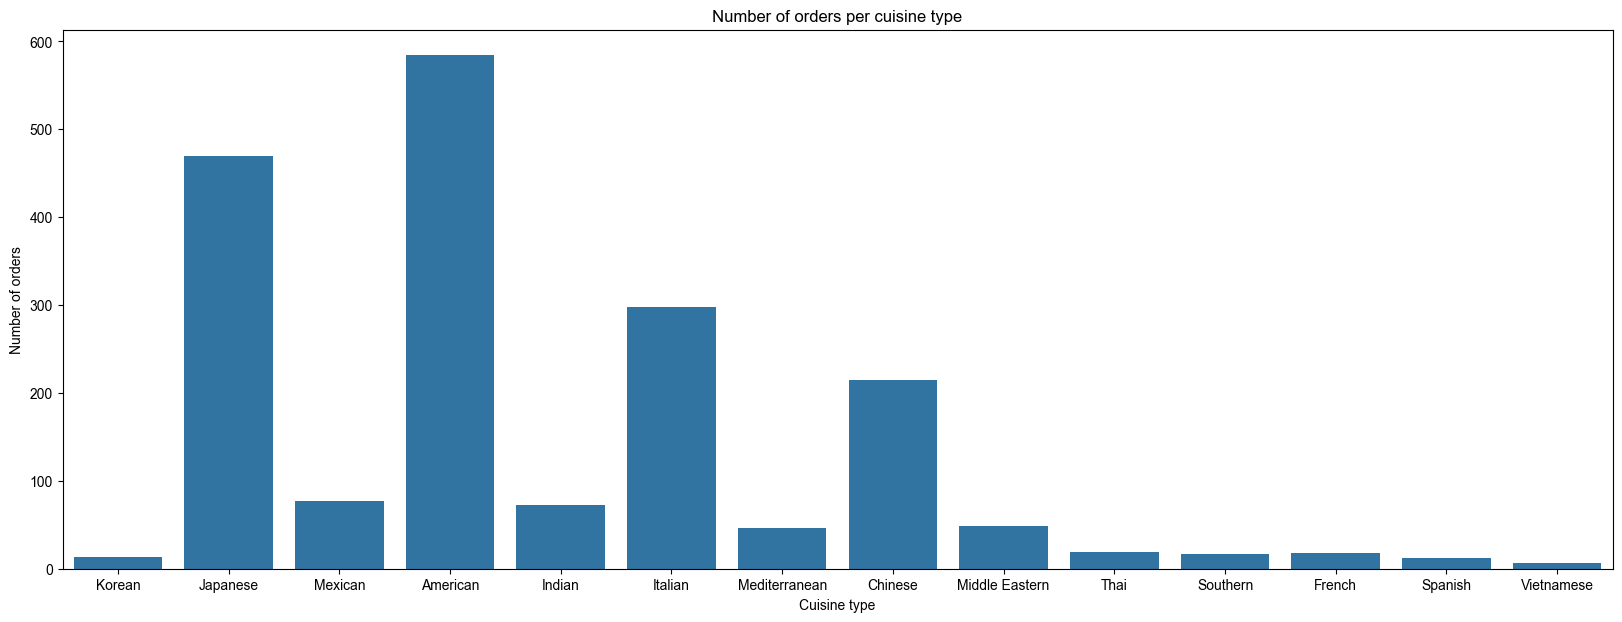

In [94]:
plt.figure(figsize=(20,7)) # set the figure size
sns.countplot(data=df, x='cuisine_type') # plot the count of orders per cuisine type
plt.ylabel("Number of orders") # set the y-axis label
plt.xlabel("Cuisine type") # set the x-axis label
plt.title("Number of orders per cuisine type") # set the title
plt.show()


#### Observations:
- The number of orders by cuisine type is not uniformly distributed, showing that there is a high variability in the customer preference for the type of food they order.
- The greatest number of orders are for 'American' cuisine type, followed by 'Japanese', 'Italian' and 'Chinese'. These separate pretty much from all the others, indicating a high interest for these type of dishes.
- On the opposite end, the lowest number of orders have been for 'Vietnamese' cuisine. 

#### Cost of the order variable analysis

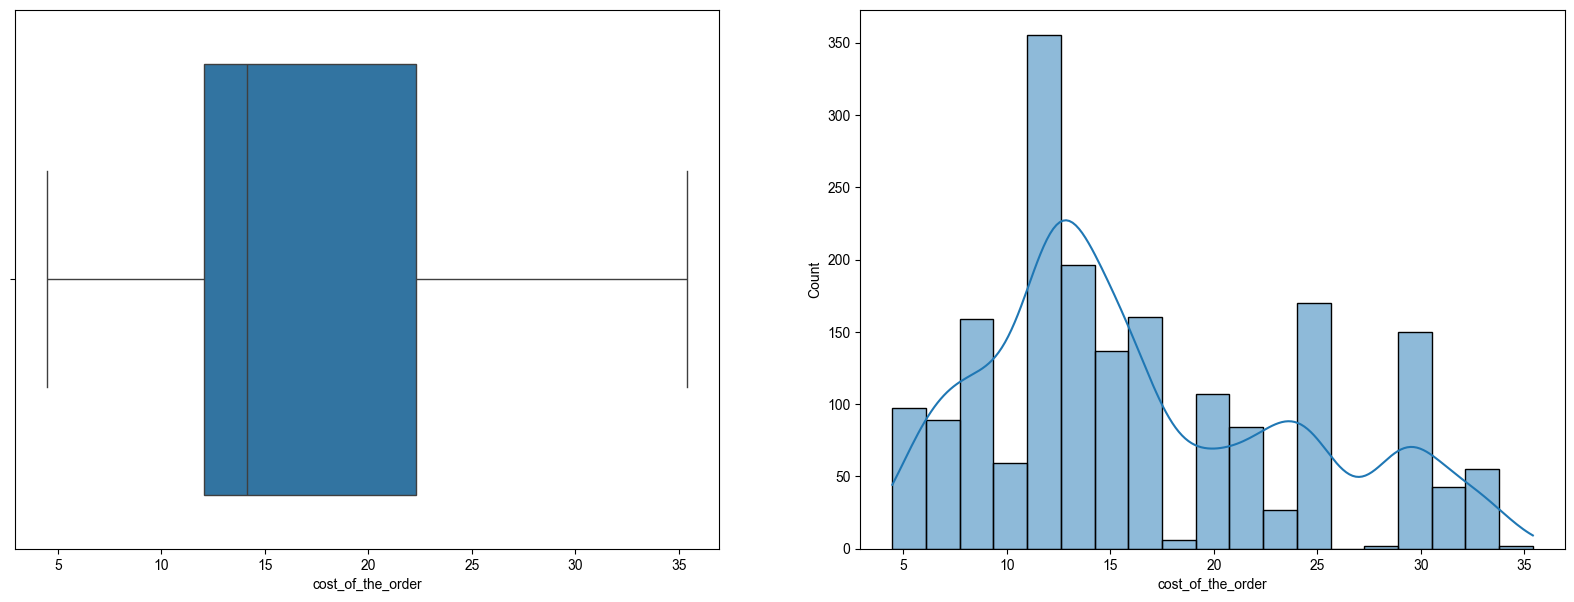

In [95]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7)) # create a figure with two subplots
sns.boxplot(data=df, x='cost_of_the_order', ax=ax1) # plot the boxplot
sns.histplot(data=df, x='cost_of_the_order', kde=True, ax=ax2) # plot the histogram
plt.show()

#### Observations:
- The distribution of 'cost_of_the_order' is right-skewed.
- However, it seems there are no outliers in the data.
- Since the distribution has multiple peaks, it seem to be a multimodal distribution.

#### Day of the week variable analysis

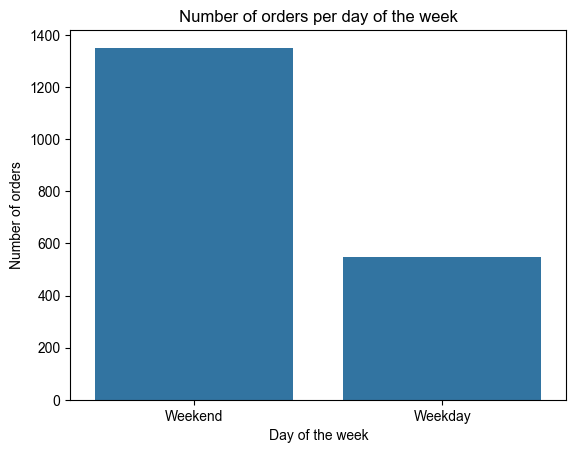

In [96]:
sns.countplot(data=df, x='day_of_the_week') # plot the count of orders per day of the week
plt.ylabel("Number of orders") # set the y-axis label
plt.xlabel("Day of the week") # set the x-axis label
plt.title("Number of orders per day of the week") # set the title
plt.show()

#### Observations:
- In the weekends there are more than 2 times more orders than in the rest of the week (weekdays).


#### Rating variable analysis

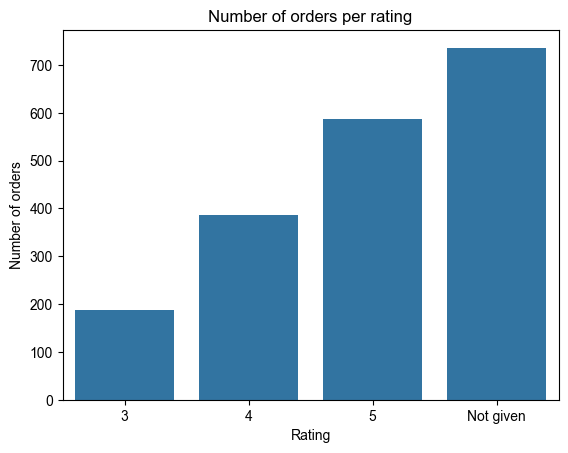

In [97]:
sns.countplot(data=df.sort_values(by='rating'), x='rating') # plot the count of orders per rating
plt.ylabel("Number of orders") # set the y-axis label
plt.xlabel("Rating") # set the x-axis label
plt.title("Number of orders per rating") # set the title
plt.show() 

#### Observations:
- Even if rating is a value out of 5, only 3, 4, 5, which are the middle to highest values have been awarded, with the largest number of orders receiving a 5 rating, then 4, then 3, of course from the ones that received a rating (ignoring the "Not given" value)
- The highest number of orders had not received a rating. It would be interesting to evaluate in the multivariate analysis whether those orders that have not received a rating could be correlated with some other variable that could suggest a low satisfaction on the customer (something like a high preparation/delivery time). We do not have enough data to assume something like this in this point.
- Because more than a third of the orders have not received a rating, it would be important to understand why that happened such that the customers be more motivated in the future to provide a rating to make the analysis even more accurate.


#### Food preparation time variable analysis

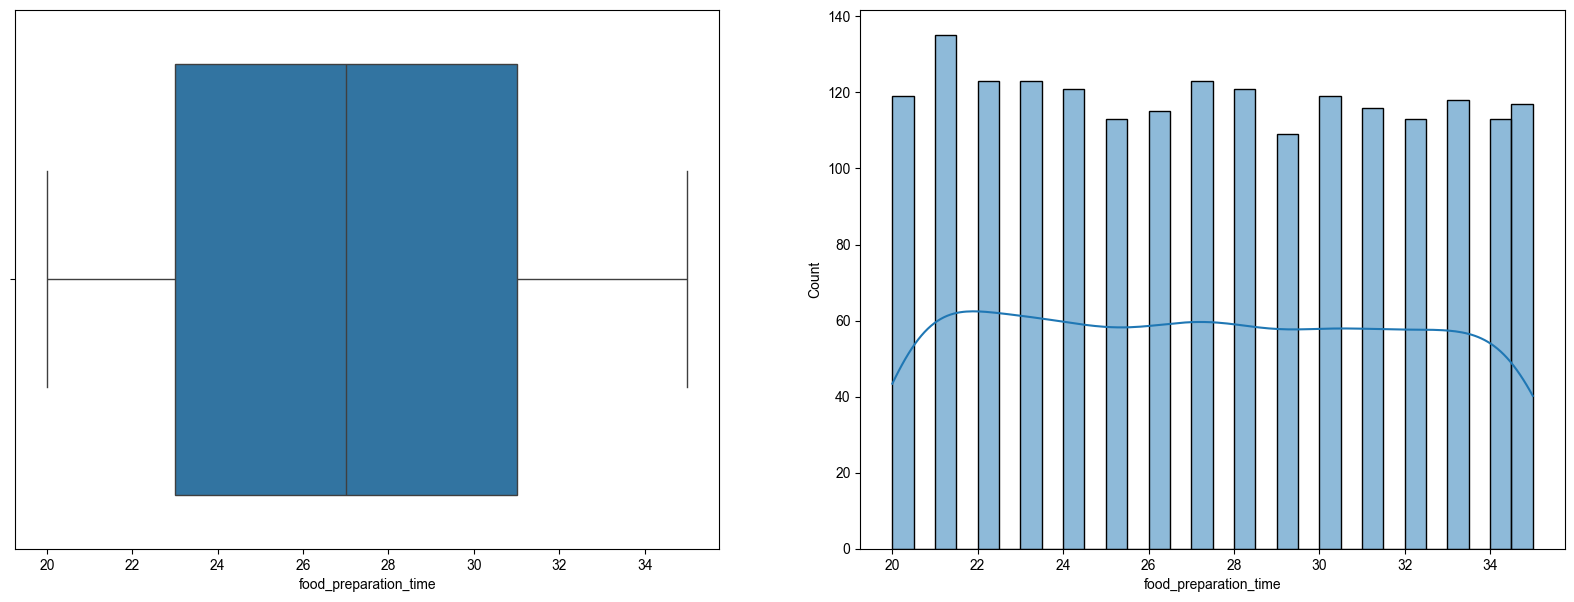

In [98]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7)) # create a figure with two subplots
sns.boxplot(data=df, x='food_preparation_time', ax=ax1) # plot the boxplot
sns.histplot(data=df, x='food_preparation_time', kde=True, ax=ax2, binwidth=0.5) # plot the histogram
plt.show() 

#### Observations:
- The distribution of 'food_preparation_time' almost shows no skew - with mean and median almost equal.
- Also, there are no outliers.
- The 'food_preparation_time' feature of the observations seems to be uniformly distributed.

#### Delivery time variable analysis

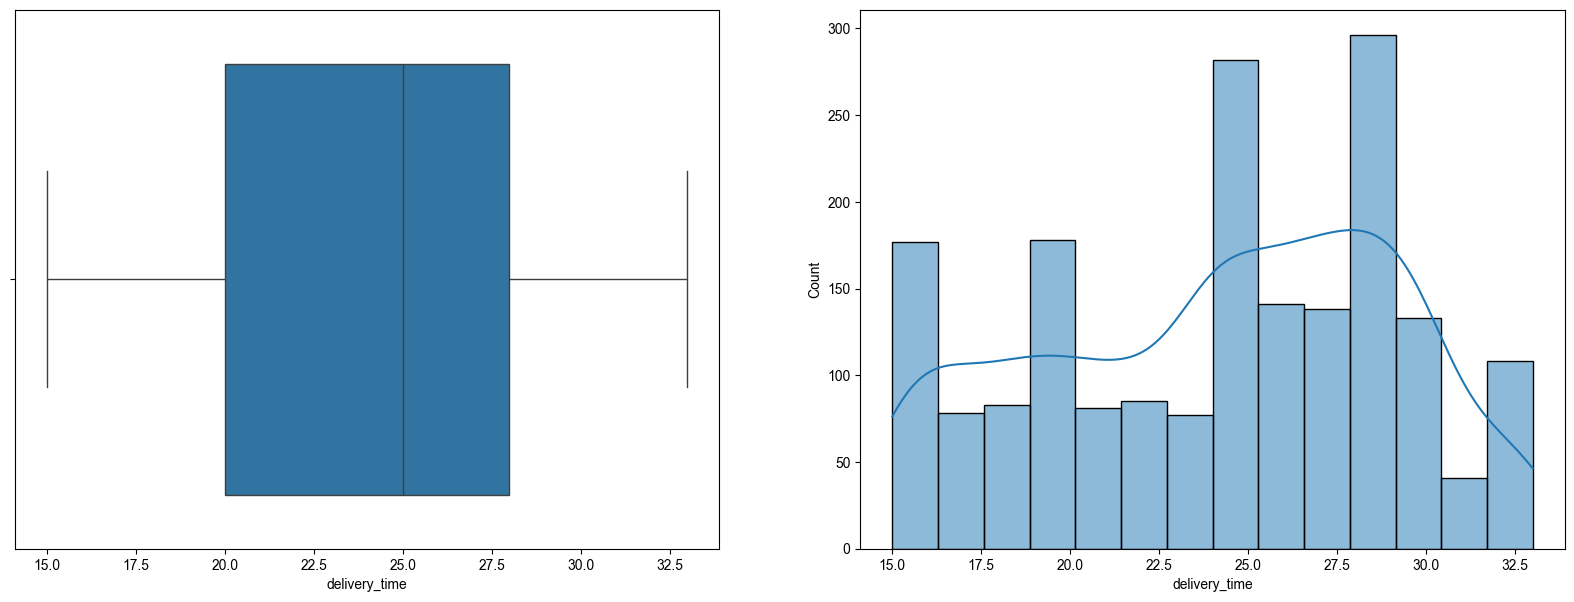

In [99]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7)) # create a figure with two subplots
sns.boxplot(data=df, x='delivery_time', ax=ax1) # plot the boxplot
sns.histplot(data=df, x='delivery_time', kde=True, ax=ax2) # plot the histogram
plt.show()

#### Observations:
- The distribution of 'delivery_time' is left-skewed.
- Also, there are no outliers.
- Since the distribution has multiple peaks, it seem to be a multimodal distribution (almost bimodal).

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [100]:
# Write the code here
df.groupby('restaurant_name')['order_id'].count().sort_values(ascending=False).head() # group by restaurant name and count the number of orders, sort the values in descending order and return the top 5

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: order_id, dtype: int64

#### Observations:

After counting the number of orders for each restaurant and sorting them in descending order, the result shows that the following are the top 5 ones in terms of the number of orders received (in this order):
- Shake Shack
- The Meatball Shop
- Blue Ribbon Sushi
- Blue Ribbon Fried Chicken
- Parm



### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [101]:
# Write the code here
is_weekend_order = df['day_of_the_week'] == 'Weekend' # predicate to check if the order is on the weekend
weekend_orders = df[is_weekend_order] # filter the orders on the weekend
print("The number of orders on the weekend is", is_weekend_order.sum()) 

weekend_orders['cuisine_type'].value_counts(ascending=False).head() # count the number of orders per cuisine type on the weekend

The number of orders on the weekend is 1351


cuisine_type
American    415
Japanese    335
Italian     207
Chinese     163
Mexican      53
Name: count, dtype: int64

#### Observations:

Out of the 1898 orders, in weekend there were 1351 orders.

Out of the weekend orders, the most popular cuisine is 'American' with 415 orders.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [102]:
# # Write the code here
orders_over_20_dollars = (df['cost_of_the_order'] > 20).sum() # count the number of orders over $20
total_orders = df.shape[0] # count the total number of orders   
percentage_of_orders_over_20_dollars = (orders_over_20_dollars / total_orders) * 100 # calculate the percentage of orders over $20
print("The percentage of orders over $20 is", round(percentage_of_orders_over_20_dollars, 2), "%") 

The percentage of orders over $20 is 29.24 %


#### Observations:
- By divining the number of orders with a cost over 20 by the total number of orders, the result shows that 29.24% of the orders cost more than 20 dollars.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [103]:
# Write the code here
round(df['delivery_time'].mean(), 2)

np.float64(24.16)

#### Observations:
The mean delivery time is 24.16. This was already seen above as well in the statistics returned by decribe function.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [104]:
# Write the code here
df.groupby('customer_id')['order_id'].count().sort_values(ascending=False).head(3) # count the number of orders per customer and sort the values in descending order

customer_id
52832    13
47440    10
83287     9
Name: order_id, dtype: int64

#### Observations:

The top 3 most frequent customers (the ones with the largest number of orders) are the following customer ids:
- 52832 with 13 orders
- 47440 with 10 orders
- 83287 with 9 orders


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


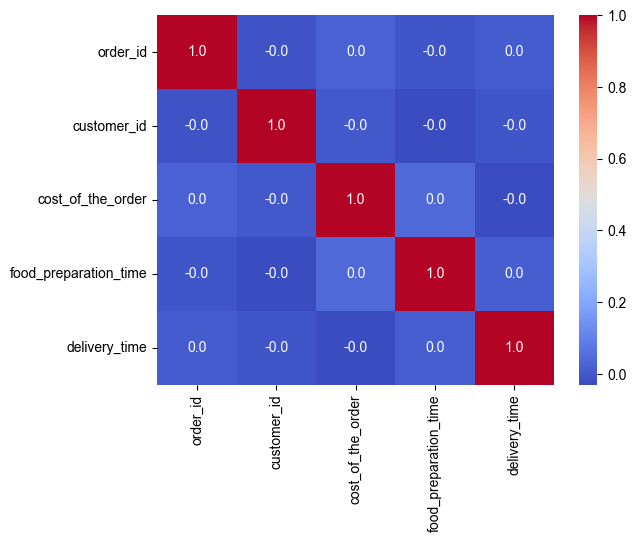

In [105]:
# Write the code here
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.1f') # plot the heatmap
plt.show() # show the plot

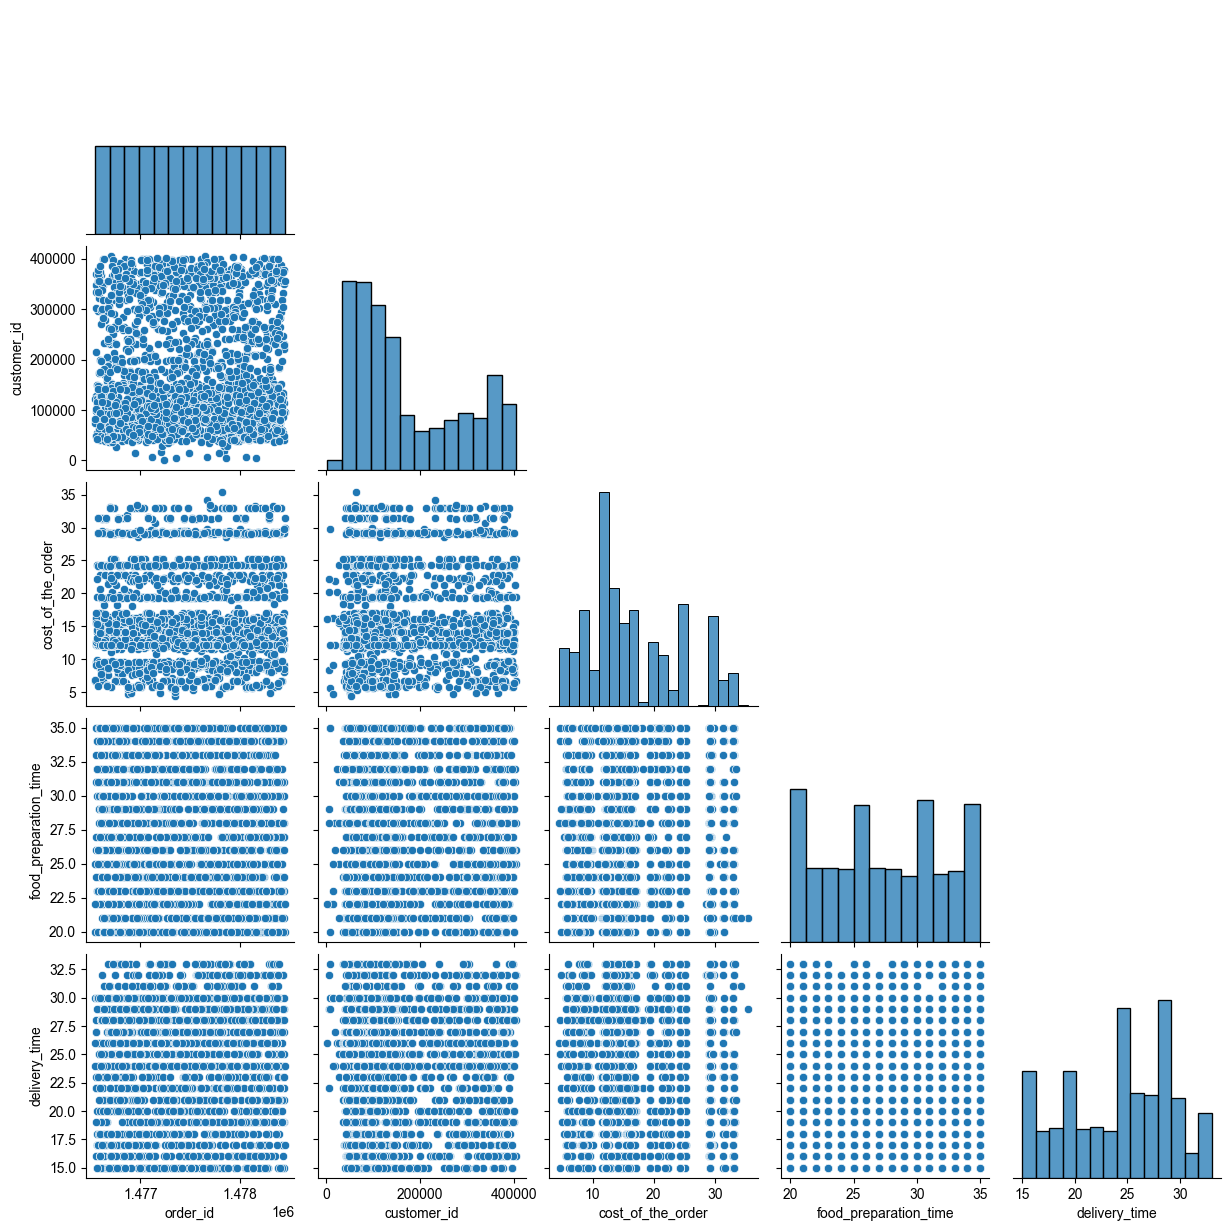

In [106]:
sns.pairplot(df, corner=True) # plot the pairplot

#### Observations:
According to both the heatmap and pairplot, there is no strong correlation between any of the numerical variables.

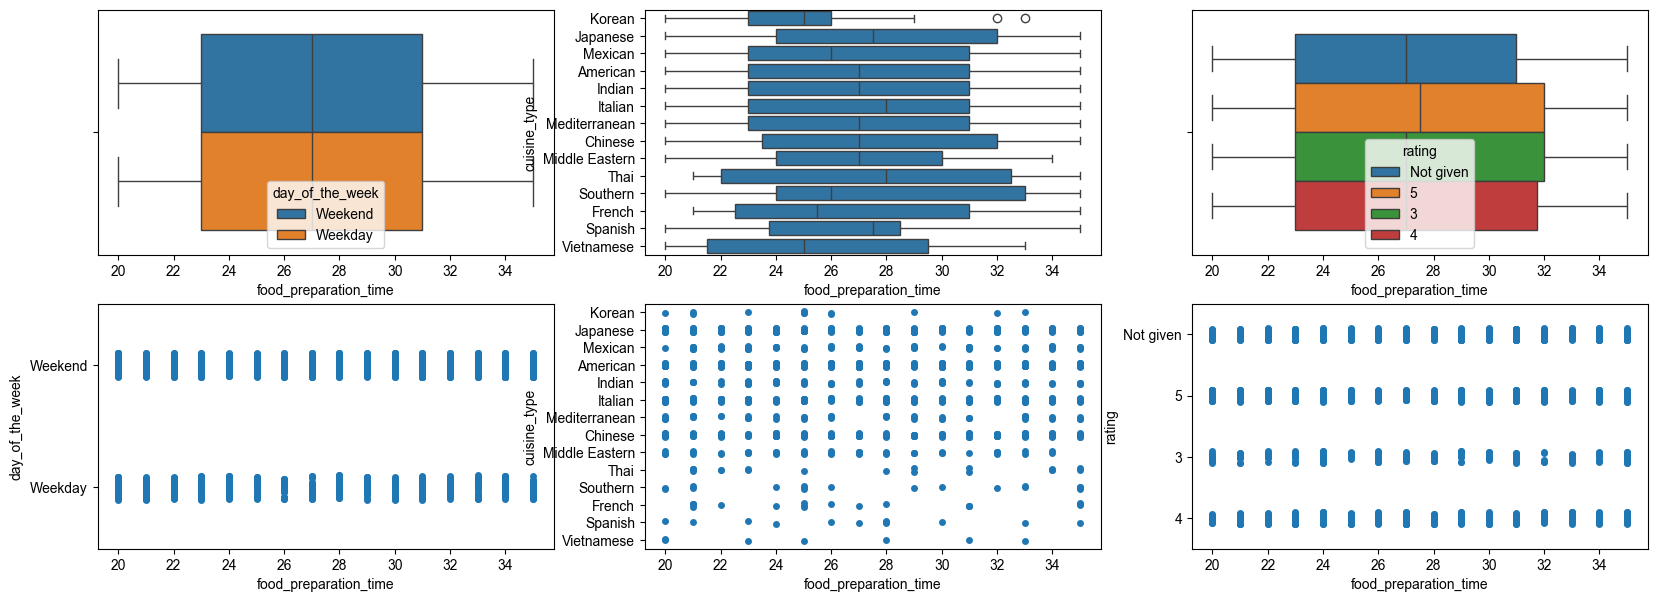

In [107]:
fig, ax = plt.subplots(2, 3, figsize=(20, 7)) # create a figure with two rows and three columns
sns.boxplot(data=df, x='food_preparation_time', hue='day_of_the_week', ax=ax[0, 0])
sns.boxplot(data=df, x='food_preparation_time', y='cuisine_type', ax=ax[0, 1])
sns.boxplot(data=df, x='food_preparation_time', hue='rating', ax=ax[0, 2])
sns.stripplot(data=df, x='food_preparation_time', y='day_of_the_week', ax=ax[1, 0])
sns.stripplot(data=df, x='food_preparation_time', y='cuisine_type', ax=ax[1, 1])
sns.stripplot(data=df, x='food_preparation_time', y='rating', ax=ax[1, 2])
plt.show()

#### Observations:
By associating the food preparation time with the categorical variables, we can notice that:
- the food preparation time does not vary with the day of the week, having the same median
- as expected, depending on the complexity and type of dish, the food preparation time varies with the cuisine type
    - depending on the type of cuisine the median is higher or lower
    - some of the cuisines have outliers (such as Korean) 
    - some of them are skewed, either positively (such as French) or negatively (such as Italian)
- the food preparation time does not influence the rating of the order

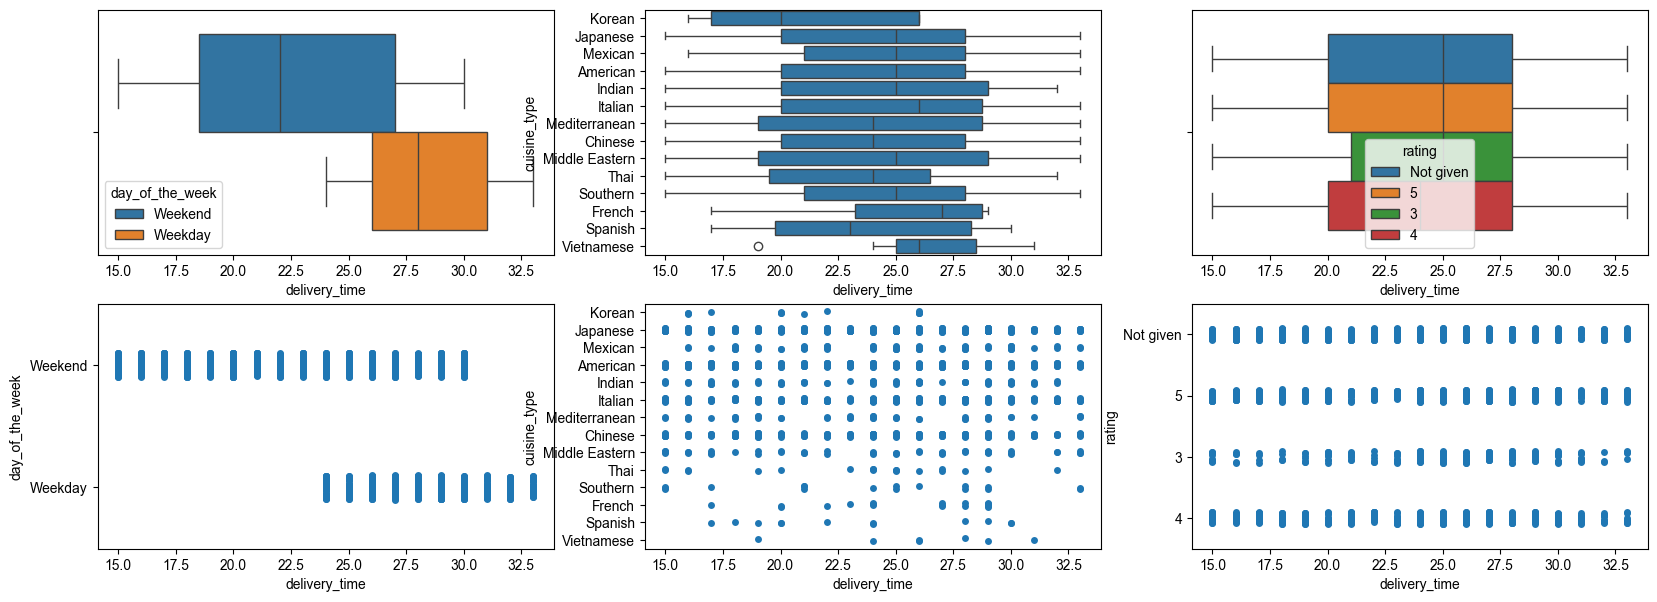

In [108]:
fig, ax = plt.subplots(2, 3, figsize=(20, 7)) # create a figure with two rows and three columns
sns.boxplot(data=df, x='delivery_time', hue='day_of_the_week', ax=ax[0, 0])
sns.boxplot(data=df, x='delivery_time', y='cuisine_type', ax=ax[0, 1])
sns.boxplot(data=df, x='delivery_time', hue='rating', ax=ax[0, 2])
sns.stripplot(data=df, x='delivery_time', y='day_of_the_week', ax=ax[1, 0])
sns.stripplot(data=df, x='delivery_time', y='cuisine_type', ax=ax[1, 1])
sns.stripplot(data=df, x='delivery_time', y='rating', ax=ax[1, 2])
plt.show()

#### Observations:
By associating the delivery time with the categorical variables, we can notice that:
- the delivery time is higher in the weekdays than in the weekend, probably due to increased traffic (people comutting to work)
- the delivery time varies with the cuisine type, having the greatest median for cuisine types as Vietnamese, Italian and French, probably due to the fact that there might exist fewer restaurants for these, so the distances to customer houses being larger
- the food delivery time does not influence the rating of the order

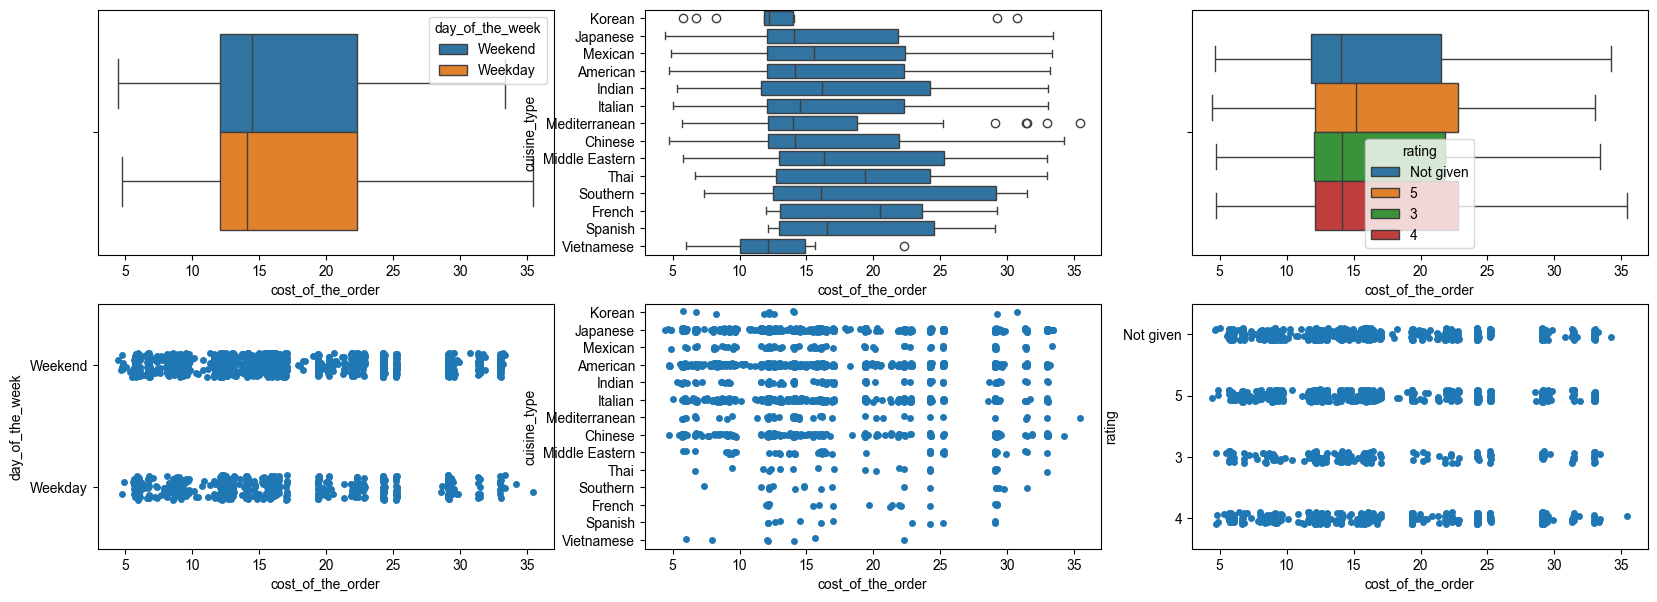

In [109]:
fig, ax = plt.subplots(2, 3, figsize=(20, 7)) # create a figure with two rows and three columns
sns.boxplot(data=df, x='cost_of_the_order', hue='day_of_the_week', ax=ax[0, 0])
sns.boxplot(data=df, x='cost_of_the_order', y='cuisine_type', ax=ax[0, 1])
sns.boxplot(data=df, x='cost_of_the_order', hue='rating', ax=ax[0, 2])
sns.stripplot(data=df, x='cost_of_the_order', y='day_of_the_week', ax=ax[1, 0])
sns.stripplot(data=df, x='cost_of_the_order', y='cuisine_type', ax=ax[1, 1])
sns.stripplot(data=df, x='cost_of_the_order', y='rating', ax=ax[1, 2])
plt.show()

#### Observations:
By associating the cost of the order with the categorical variables, we can notice that:
- the cost is almost the same during weekend and weekdays, however with a slightly lower median during weekdays (there might be some discounts)
- as expected, depending on the complexity and type of dish, the cost varies with the cuisine type
    - depending on the type of cuisine the median is higher or lower, the highest median being for French, wile the lowest being for Vietnamese
    - some of the cuisines have outliers (such as Korean and Mediterranean) 
    - all of them are skewed, probably due to variety in number of dishes and/or the price of the dish in an order
- the cost time does not influence whether the people are providing reviews or not. Also the '5' rating has a higher median of cost, showing that multiple customers with more expensive orders provided a '5' review, compared to the others.

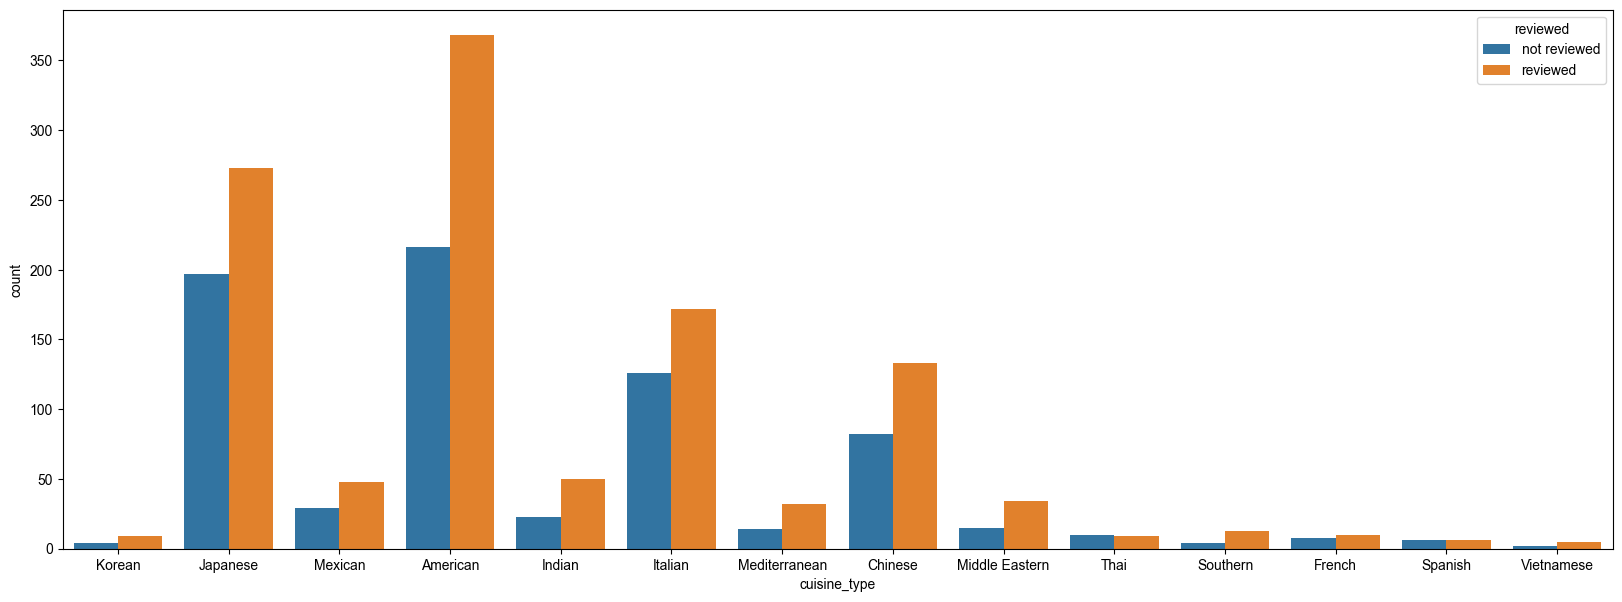

In [110]:
plt.figure(figsize = (20, 7)) # set the figure size
withReviews = df.copy() # copy the dataframe
withReviews['reviewed'] = withReviews['rating'].map(lambda x: 'not reviewed' if x == 'Not given' else 'reviewed') # map the rating to 'not reviewed' if it is 'Not given' else 'reviewed'
sns.countplot(data=withReviews, x='cuisine_type', hue='reviewed') # plot the count of orders per cuisine type
plt.show()


#### Observations:
The missing reviews cannot be associated with a cuisine type.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [111]:
# Write the code here
data_with_reviews = df[df['rating'] != 'Not given'] # filter the dataframe to only include orders with reviews
grouped = data_with_reviews.astype({'rating': 'int64'}).groupby('restaurant_name').agg({'rating': ['mean', 'count']}) # group the dataframe by restaurant name and calculate the mean and count of the ratings
grouped[(grouped['rating', 'mean'] > 4) & (grouped['rating', 'count'] > 50)].sort_values(by=('rating','mean'), ascending=False) # filter the dataframe to only include restaurants with a mean rating greater than 4 and a count of orders greater than 50


rating      
                               mean count
restaurant_name                          
The Meatball Shop          4.511905    84
Blue Ribbon Fried Chicken  4.328125    64
Shake Shack                4.278195   133
Blue Ribbon Sushi          4.219178    73

#### Observations:
Note: from the definition of the question I assumed that `rating count of more than 50` means that the requirement was that the  restaurant was reviewed more than 50 times, and not that the sum of reviews is more than 50.

The restaurants that have received more than 50 reviews and have an average grater than 4 (ordered descending by rating average) are:
- The Meatball Shop	
- Blue Ribbon Fried Chicken	
- Shake Shack	
- Blue Ribbon Sushi	

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [112]:
# Write the code here
def calculate_revenue(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0
    
float(df['cost_of_the_order'].map(lambda x: calculate_revenue(x)).sum()) # calculate the total revenue

6166.303

#### Observations:
- By applyng the fee conditionally based on the cost of the order, the total revenue generated across all orders is 6166.3 dollars.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [113]:
# Write the code here
new_df = df.copy() # copy the dataframe
new_df['total_time'] = new_df['food_preparation_time'] + new_df['delivery_time'] # calculate the total time

orders_over_60_minutes = (new_df['total_time'] > 60).sum() # count the number of orders over 60 minutes
total_orders = new_df.shape[0] # count the total number of orders
percentage_of_orders_over_60_minutes = (orders_over_60_minutes / total_orders) * 100 # calculate the percentage of orders over 60 minutes
print("The percentage of orders over 60 minutes is", round(percentage_of_orders_over_60_minutes, 2), "%") 

The percentage of orders over 60 minutes is 10.54 %


#### Observations:
The total time is food preparation time + delivery time. Out of the total number of orders, 10.54% had a total time over 60 minutes from the moment of placing the order until the food was delivered.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [114]:
# Write the code here
orders_during_weekends = df[df['day_of_the_week'] == 'Weekend']['delivery_time'].mean() # calculate the average delivery time during weekends
orders_during_weekdays = df[df['day_of_the_week'] == 'Weekday']['delivery_time'].mean() # calculate the average delivery time during weekdays

print("The average delivery time during weekends is", orders_during_weekends, "minutes") 
print("The average delivery time during weekdays is", orders_during_weekdays, "minutes") 

The average delivery time during weekends is 22.4700222057735 minutes
The average delivery time during weekdays is 28.340036563071298 minutes


#### Observations:
- The mean of delivery time in weekdays is greater than in weekends, which is somehow expected due to more traffic of people commuting during working days.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
* Majority of customers have less than 2 orders, while there are some outliers who have placed more than 4.
* Majority of restaurants have a number of orders less than 20, while there are some outliers which have a much higher number of orders  (even 10 times higher) .
* The highest number of orders are from American, Japanese, Italian and Chinese cuisines, indicating a preference for these cuisines.
* The number of orders is higher in the weekends than in the weekdays, indicating that people are more likely to order food on the weekends.
* More than a third of the orders are not reviewed, making the analysis of the customer satisfaction incomplete. The ratings that have been provided are only between 3-5, suggesting that the customers with low satisfaction might have not provided a review. However, this assumption was not proven by the association between the missing reviews and the variables that could contribute to the customer satisfaction (delivery time and cost).
* The food preparation time is uniformly distributed, while the delivery time is left-skewed, indicating that the average total time is mostly influenced by the delivery time.
* The delivery time is higher in the weekdays than in the weekend, one possible explanation being that it is influenced by the traffic.
* Also the delivery time is influenced by the cuisine type, indicating that some restaurants (for some not so popular cuisines, such as Vietnamese) might not be located as close to the customers as others.
* The cost of the order is influenced by the cuisine type as well and it is correlated with the number of orders, indicating that the popularity of some cuisines (the top 4 mentioned above) might be influenced by the low cost of the orders as well.

### Recommendations:

* The customer retention seems to be a problem. The fact that the number of orders per customer is so low, might indicate some problems in the customer experience with the app, since all the others variable do not provide a strong correlation. Also, using new strategies to make more customers place more orders might help as well. 
* The high number of orders that are placed during the weekend have to be leveraged as much as possible, becaused then the customers are more likely to order food.
* The high interest in the American, Japanese, Italian and Chinese cuisines shows a growth potential in collaboration with even more restaurants that offer these cuisines.
* The restaurants that create the highest revenue are the ones that could have some lower charges applied, together with a price discount from the restaurants such that it would encourage the customers place even more orders creating higher revenues for both the app and restaurants.
* The customer should be stimulated to leave a review, by offering a discount for the next order, such that the future satisfaction analysis performed on the data will be more accurate.
* Creating some discounts for the not so popular cuisines (other than the top 4), might increase the number of orders for them as well.

---